In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [140]:
df = pd.read_csv('IRIS[1].csv')

# Basic Data Understand

In [121]:
df.shape

(150, 5)

In [122]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
72,6.3,2.5,4.9,1.5,Iris-versicolor
122,7.7,2.8,6.7,2.0,Iris-virginica
35,5.0,3.2,1.2,0.2,Iris-setosa
81,5.5,2.4,3.7,1.0,Iris-versicolor
37,4.9,3.1,1.5,0.1,Iris-setosa


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [124]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [125]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Data Cleaning

In [126]:
df[df.duplicated(keep=False)]

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


In [127]:
df.drop_duplicates(inplace=True)

In [128]:
df.shape

(147, 5)

In [129]:
df.duplicated().sum()

np.int64(0)

In [130]:
df.iloc[:,:-1].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


# Univariate Analysis

<Axes: xlabel='species'>

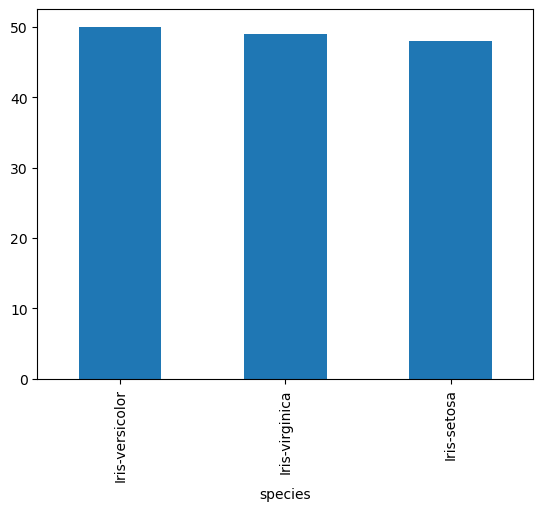

In [131]:
df['species'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

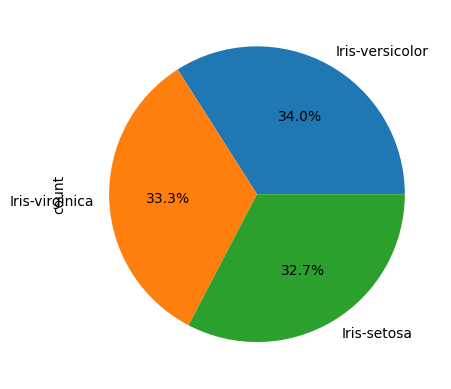

In [132]:
df['species'].value_counts().plot(kind='pie', autopct='%1.1f%%')

(array([ 9., 21., 14., 27., 15., 26., 18.,  6.,  5.,  6.]),
 array([4.3 , 4.66, 5.02, 5.38, 5.74, 6.1 , 6.46, 6.82, 7.18, 7.54, 7.9 ]),
 <BarContainer object of 10 artists>)

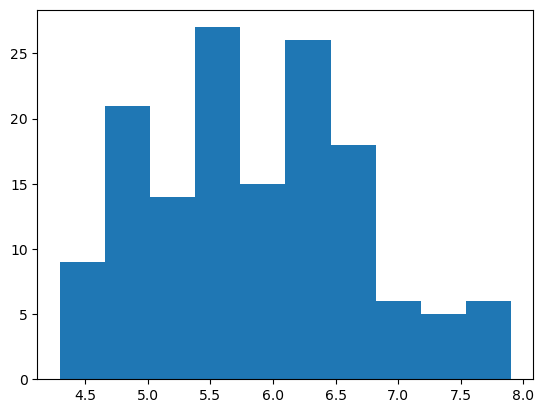

In [133]:
plt.hist(df['sepal_length'])

In [134]:
df.iloc[:,:-1].skew()

sepal_length    0.292560
sepal_width     0.324351
petal_length   -0.293763
petal_width    -0.113479
dtype: float64

# Bivariate Analysis


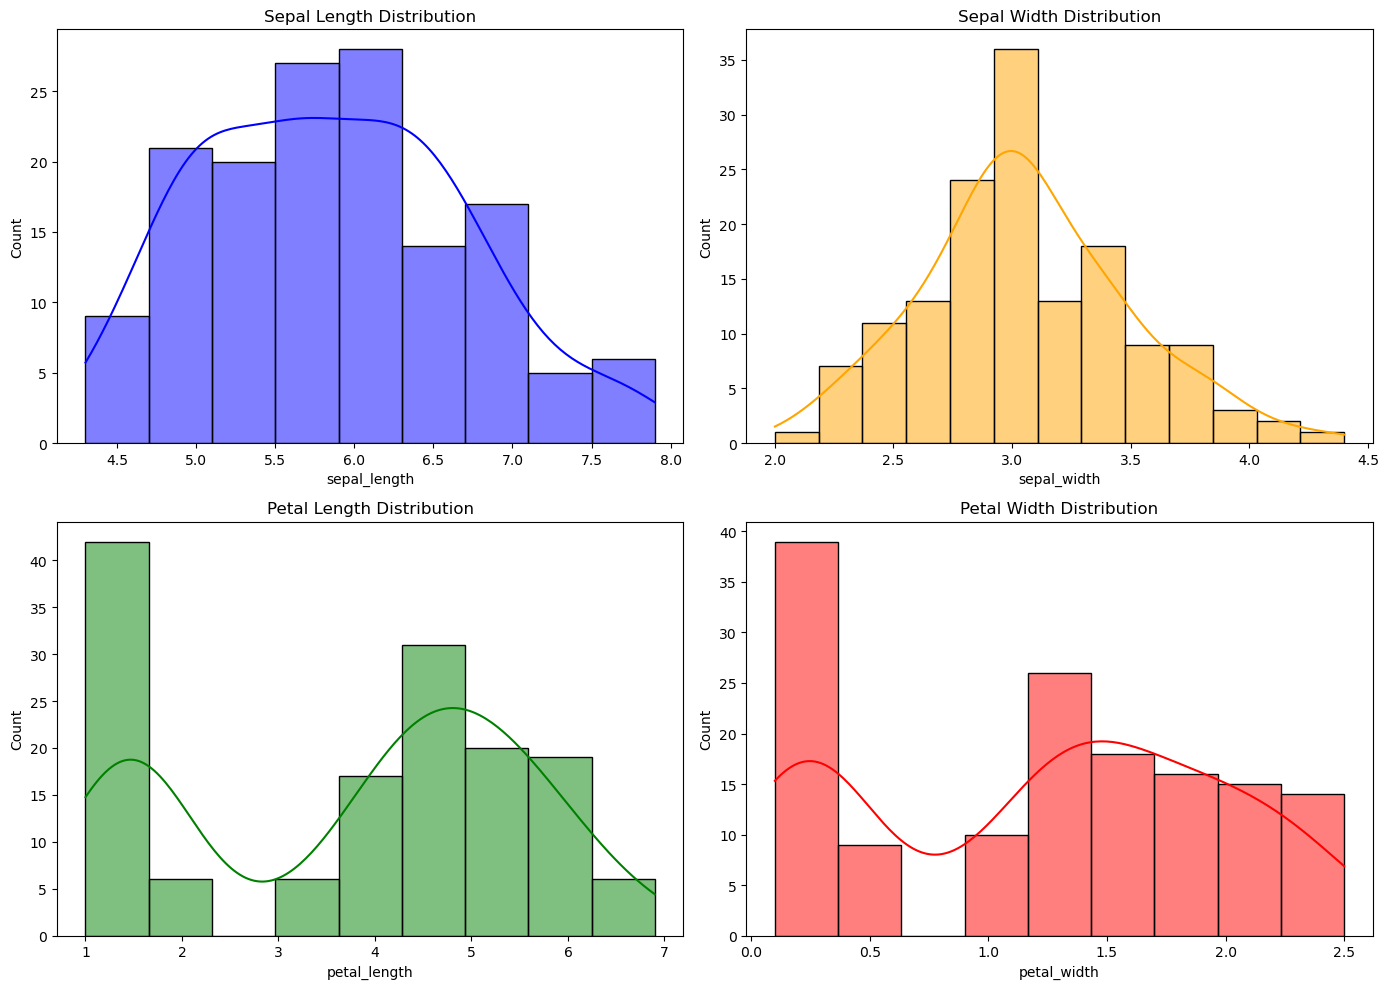

In [135]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['sepal_length'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Sepal Length Distribution')

sns.histplot(df['sepal_width'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Sepal Width Distribution')

sns.histplot(df['petal_length'], kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Petal Length Distribution')

sns.histplot(df['petal_width'], kde=True, color='red', ax=axes[1, 1])
axes[1, 1].set_title('Petal Width Distribution')

plt.tight_layout()
plt.show()

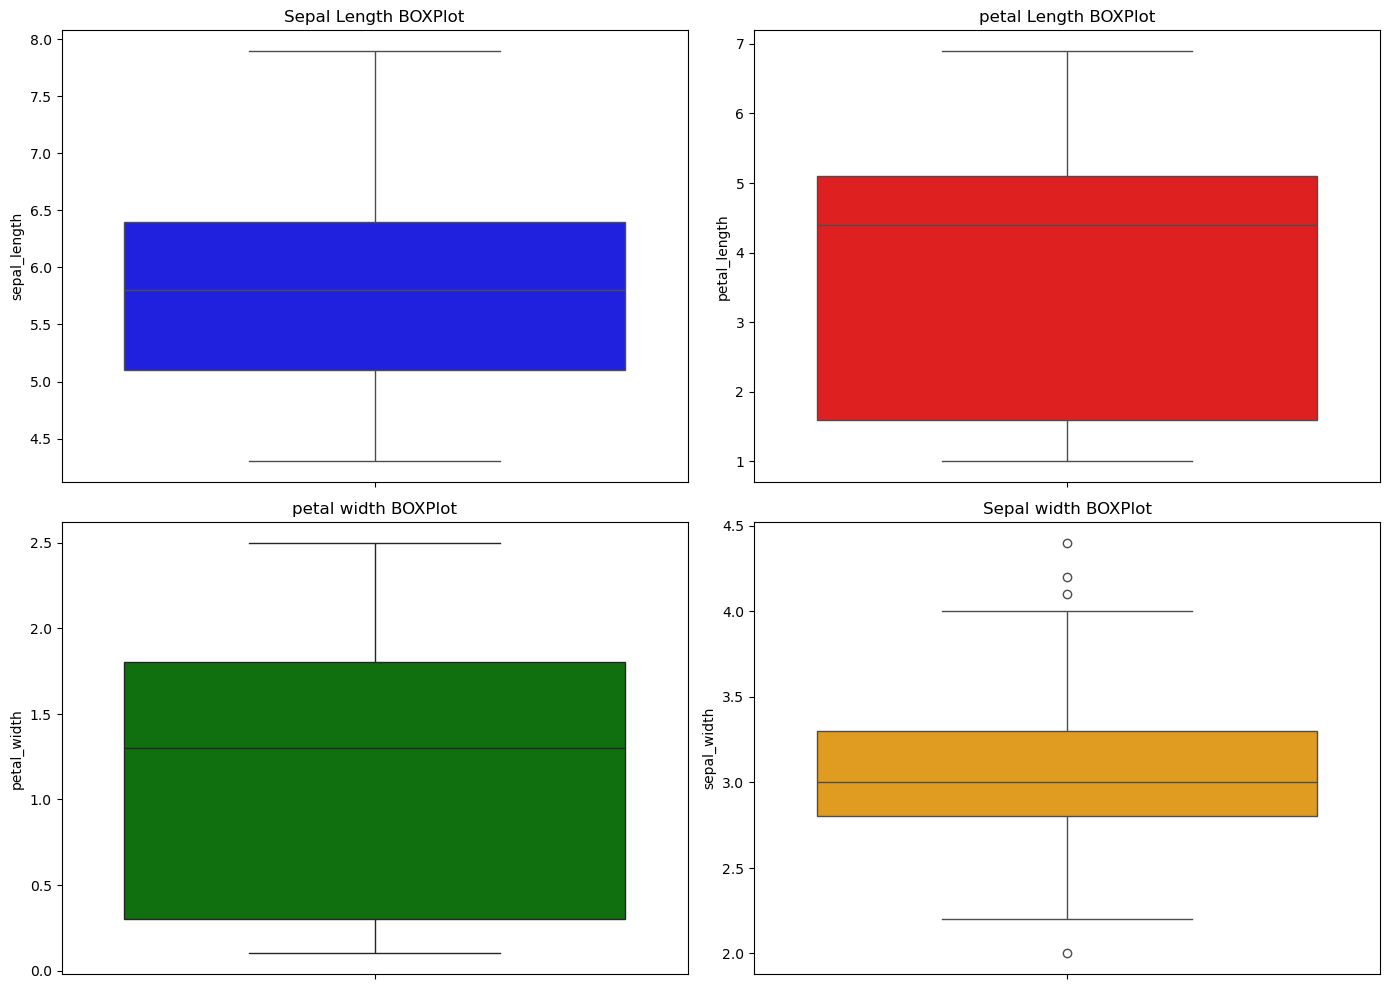

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(df['sepal_length'],color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Sepal Length BOXPlot')

sns.boxplot(df['petal_length'],color='red', ax=axes[0, 1])
axes[0, 1].set_title('petal Length BOXPlot')

sns.boxplot(df['petal_width'],color='green', ax=axes[1, 0])
axes[1, 0].set_title('petal width BOXPlot')

sns.boxplot(df['sepal_width'],color='orange', ax=axes[1,1])
axes[1, 1].set_title('Sepal width BOXPlot')

plt.tight_layout()
plt.show()

In [137]:
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['sepal_width'] < lower_bound) | (df['sepal_width'] > upper_bound)]
print(outliers)

    sepal_length  sepal_width  petal_length  petal_width          species
15           5.7          4.4           1.5          0.4      Iris-setosa
32           5.2          4.1           1.5          0.1      Iris-setosa
33           5.5          4.2           1.4          0.2      Iris-setosa
60           5.0          2.0           3.5          1.0  Iris-versicolor


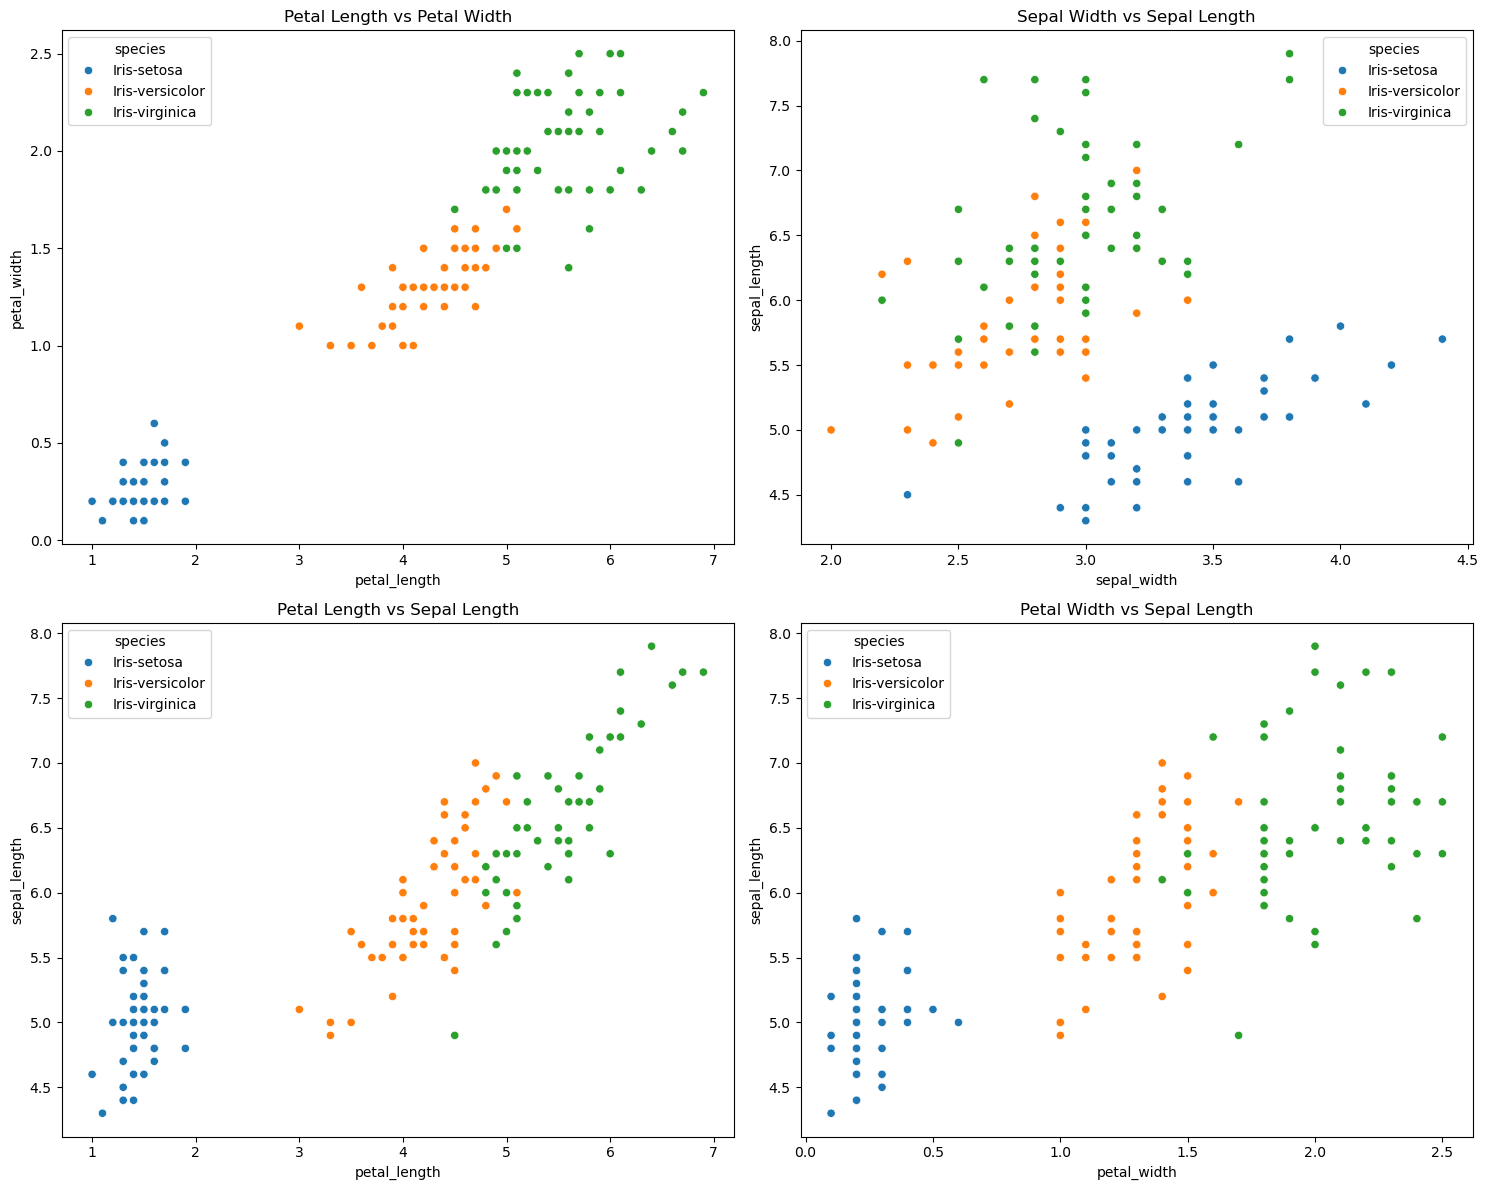

In [138]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=axes[0, 0])
axes[0, 0].set_title('Petal Length vs Petal Width')

sns.scatterplot(data=df, x='sepal_width', y='sepal_length', hue='species', ax=axes[0, 1])
axes[0, 1].set_title('Sepal Width vs Sepal Length')

sns.scatterplot(data=df, x='petal_length', y='sepal_length', hue='species', ax=axes[1, 0])
axes[1, 0].set_title('Petal Length vs Sepal Length')

sns.scatterplot(data=df, x='petal_width', y='sepal_length', hue='species', ax=axes[1, 1])
axes[1, 1].set_title('Petal Width vs Sepal Length')

plt.tight_layout()
plt.show()

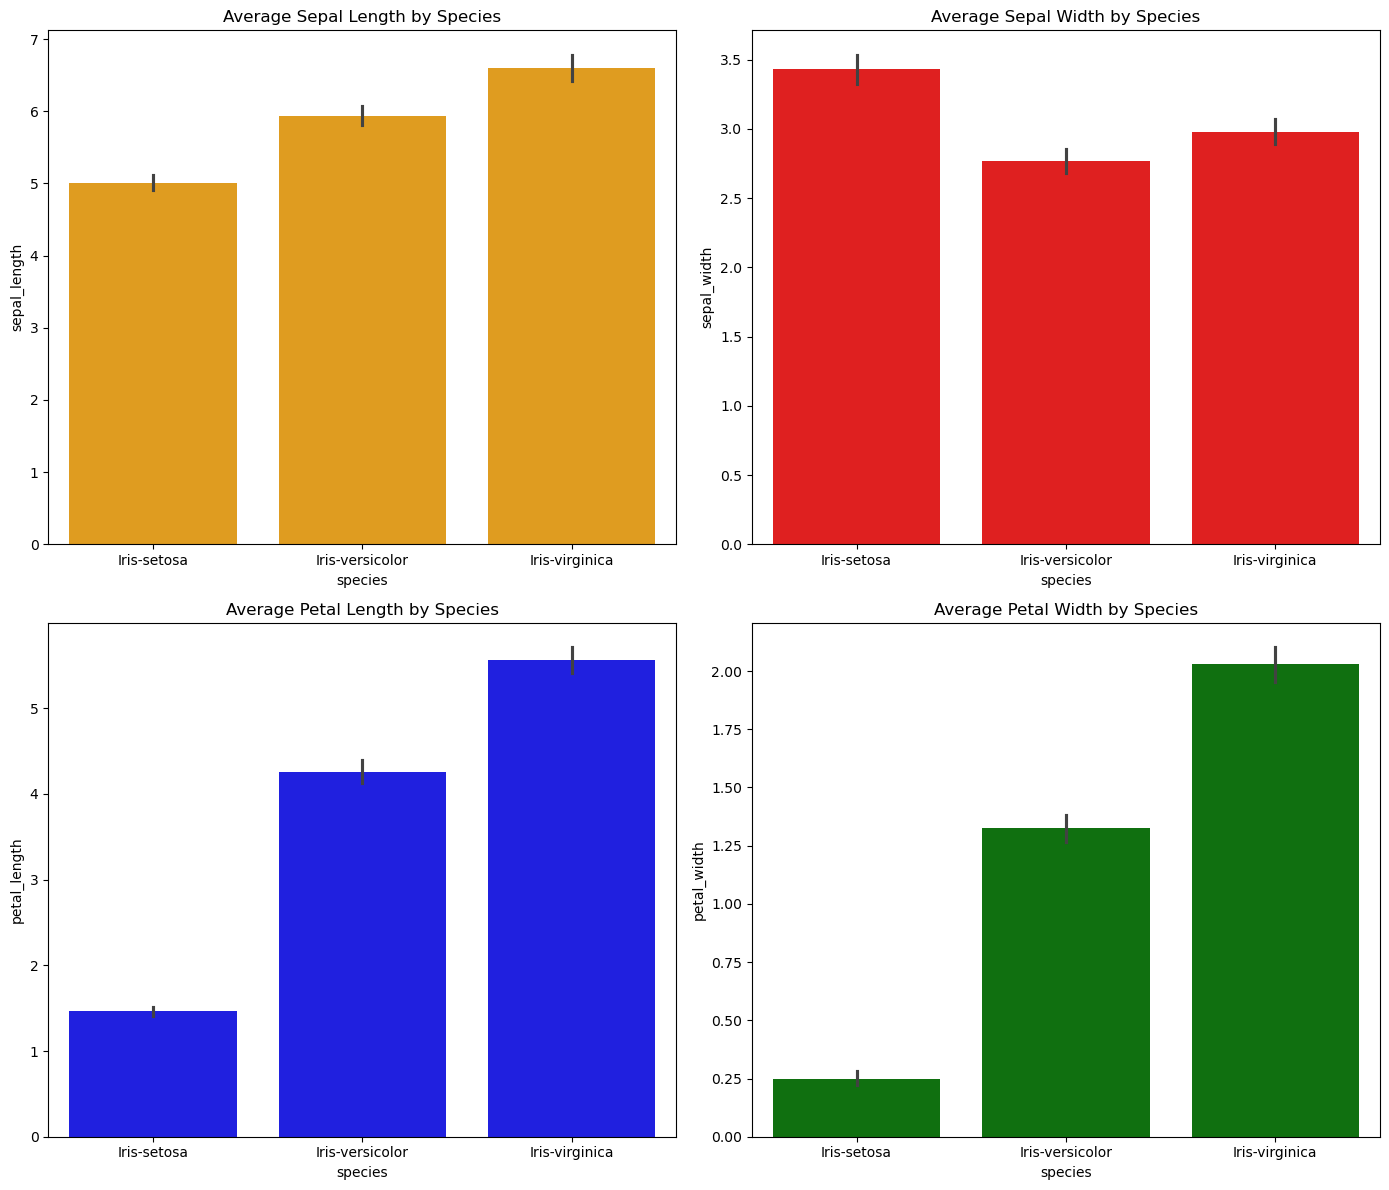

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.barplot(x='species', y='sepal_length', data=df, ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Average Sepal Length by Species')

sns.barplot(x='species', y='sepal_width', data=df, ax=axes[0, 1], color='red')
axes[0, 1].set_title('Average Sepal Width by Species')

sns.barplot(x='species', y='petal_length', data=df, ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Average Petal Length by Species')

sns.barplot(x='species', y='petal_width', data=df, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Average Petal Width by Species')

plt.tight_layout()
plt.show()